# Planning Time Analysis

Analyze planning_time.csv produced by planning-time runs.

## Section 1: Import Required Libraries

Load pandas and plotting helpers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
sns.set_theme(style='whitegrid')

## Section 2: Load and Clean Planning Time CSV

Read the CSV and normalize types.

In [2]:
csv_path = Path('logs/planning_time.csv')
if not csv_path.exists():
    raise FileNotFoundError(f'Input file not found: {csv_path}')

df = pd.read_csv(csv_path, engine='python', on_bad_lines='skip')
raw_count = len(df)

if 'timestamp_utc' in df.columns:
    df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'], errors='coerce', utc=True)
if 'planning_time_ms' in df.columns:
    df['planning_time_ms'] = pd.to_numeric(df['planning_time_ms'], errors='coerce')
if 'execution_time_ms' in df.columns:
    df['execution_time_ms'] = pd.to_numeric(df['execution_time_ms'], errors='coerce')
if 'exit_code' in df.columns:
    df['exit_code'] = pd.to_numeric(df['exit_code'], errors='coerce')
if 'run_index' in df.columns:
    df['run_index'] = pd.to_numeric(df['run_index'], errors='coerce')
    df = df[df['run_index'].fillna(-1) != 1]

print(f'Rows loaded: {raw_count}')
print(f'Rows after dropping run_index == 1: {len(df)}')
display(df.head())

df.info()

Rows loaded: 1000
Rows after dropping run_index == 1: 990


,timestamp_utc,run_id,test_name,loop_index,run_index,planning_time_ms,execution_time_ms,exit_code,source_query_file,query_dir,query_filter,run_started_utc
1,2026-05-16 19:25:57+00:00,B7352F5D29F0EEA1,APX1090-queryA.sql,1,2,0.354,1122.317,0,queries/APX1090-queryA.sql,queries,APX1090,2026-05-16T19:25:54Z
2,2026-05-16 19:25:58+00:00,B7352F5D29F0EEA1,APX1090-queryA.sql,1,3,0.311,1117.800,0,queries/APX1090-queryA.sql,queries,APX1090,2026-05-16T19:25:54Z
3,2026-05-16 19:25:59+00:00,B7352F5D29F0EEA1,APX1090-queryA.sql,1,4,0.304,1116.554,0,queries/APX1090-queryA.sql,queries,APX1090,2026-05-16T19:25:54Z
4,2026-05-16 19:26:00+00:00,B7352F5D29F0EEA1,APX1090-queryA.sql,1,5,0.311,1115.430,0,queries/APX1090-queryA.sql,queries,APX1090,2026-05-16T19:25:54Z
5,2026-05-16 19:26:01+00:00,B7352F5D29F0EEA1,APX1090-queryA.sql,1,6,0.308,1117.351,0,queries/APX1090-queryA.sql,queries,APX1090,2026-05-16T19:25:54Z


<class 'pandas.core.frame.DataFrame'>
Index: 990 entries, 1 to 999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   timestamp_utc      990 non-null    datetime64[ns, UTC]
 1   run_id             990 non-null    object             
 2   test_name          990 non-null    object             
 3   loop_index         990 non-null    int64              
 4   run_index          990 non-null    int64              
 5   planning_time_ms   990 non-null    float64            
 6   execution_time_ms  990 non-null    float64            
 7   exit_code          990 non-null    int64              
 8   source_query_file  990 non-null    object             
 9   query_dir          990 non-null    object             
 10  query_filter       990 non-null    object             
 11  run_started_utc    990 non-null    object             
dtypes: datetime64[ns, UTC](1), float64(2), int64(3), object

In [3]:
missing_planning = df['planning_time_ms'].isna().sum() if 'planning_time_ms' in df.columns else len(df)
missing_execution = df['execution_time_ms'].isna().sum() if 'execution_time_ms' in df.columns else len(df)
failed_exit = (df['exit_code'].fillna(0) != 0).sum() if 'exit_code' in df.columns else 0

print(f'Missing planning_time_ms: {missing_planning}')
print(f'Missing execution_time_ms: {missing_execution}')
print(f'Non-zero exit_code: {failed_exit}')

Missing planning_time_ms: 0
Missing execution_time_ms: 0
Non-zero exit_code: 0


## Section 3: Per-Query Planning Time Stats

Summaries using successful runs only.

In [4]:
target_queries = ["APX1090", "APX1092", "APX1173", "PE002", "PE019"]
pattern = r"^(APX1090|APX1092|APX1173|PE002|PE019)"

if "test_name" not in df.columns:
    raise KeyError("test_name column not found in planning_time.csv")

filtered = df[df["test_name"].str.contains(pattern, regex=True, na=False)].copy()
print(f"Rows after filter: {len(filtered)}")
display(filtered["test_name"].value_counts())

valid = filtered.copy()
if "exit_code" in valid.columns:
    valid = valid[valid["exit_code"].fillna(0) == 0]
valid = valid[valid["planning_time_ms"].notna()]

def p95(x):
    return x.quantile(0.95)

def cv_pct(x):
    mean = x.mean()
    if mean == 0 or pd.isna(mean):
        return np.nan
    return x.std(ddof=1) / mean * 100

query_stats = (
    valid.groupby("test_name")["planning_time_ms"]
    .agg(["count", "mean", "median", "std", "min", "max", p95, cv_pct])
    .reset_index()
    .sort_values("median", ascending=False)
 )

exec_valid = filtered.copy()
if "exit_code" in exec_valid.columns:
    exec_valid = exec_valid[exec_valid["exit_code"].fillna(0) == 0]
if "execution_time_ms" in exec_valid.columns:
    exec_valid = exec_valid[exec_valid["execution_time_ms"].notna()]
    exec_query_stats = (
        exec_valid.groupby("test_name")["execution_time_ms"]
        .agg(["count", "mean", "median", "std", "min", "max", p95, cv_pct])
        .reset_index()
        .sort_values("median", ascending=False)
    )
else:
    exec_query_stats = pd.DataFrame()

display(query_stats)
if not exec_query_stats.empty:
    display(exec_query_stats)
else:
    print("execution_time_ms not available.")

Rows after filter: 990


C:\Users\Matthias\AppData\Local\Temp\ipykernel_2308\124752176.py:7: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  filtered = df[df["test_name"].str.contains(pattern, regex=True, na=False)].copy()


test_name
APX1090-queryA.sql    99
APX1090-queryB.sql    99
APX1092-queryA.sql    99
APX1092-queryB.sql    99
APX1173-queryA.sql    99
APX1173-queryB.sql    99
PE002-queryA.sql      99
PE002-queryB.sql      99
PE019-queryA.sql      99
PE019-queryB.sql      99
Name: count, dtype: int64

,test_name,count,mean,median,std,min,max,p95,cv_pct
5,APX1173-queryB.sql,99,0.578848,0.576,0.034723,0.528,0.696,0.6442,5.998619
8,PE019-queryA.sql,99,0.541909,0.550,0.029816,0.498,0.612,0.5910,5.502118
9,PE019-queryB.sql,99,0.538061,0.540,0.032860,0.487,0.656,0.5902,6.107154
3,APX1092-queryB.sql,99,0.387141,0.375,0.044903,0.340,0.560,0.4853,11.598564
2,APX1092-queryA.sql,99,0.379192,0.368,0.032022,0.342,0.485,0.4435,8.444688
4,APX1173-queryA.sql,99,0.348404,0.336,0.029967,0.314,0.439,0.4041,8.601209
0,APX1090-queryA.sql,99,0.327566,0.312,0.030183,0.304,0.475,0.3703,9.214388
1,APX1090-queryB.sql,99,0.293636,0.282,0.029121,0.267,0.433,0.3420,9.917470
7,PE002-queryB.sql,99,0.192293,0.179,0.029852,0.166,0.322,0.2486,15.524463
6,PE002-queryA.sql,99,0.197101,0.179,0.038940,0.169,0.332,0.3072,19.756452


,test_name,count,mean,median,std,min,max,p95,cv_pct
5,APX1173-queryB.sql,99,1939.708737,1939.182,3.164575,1936.114,1963.539,1942.6087,0.163147
4,APX1173-queryA.sql,99,1933.426384,1933.385,2.292616,1927.941,1941.372,1937.8515,0.118578
2,APX1092-queryA.sql,99,1447.199141,1446.752,2.714200,1442.158,1461.863,1451.7946,0.187548
3,APX1092-queryB.sql,99,1451.828121,1446.051,40.785202,1441.145,1748.518,1448.8019,2.809231
1,APX1090-queryB.sql,99,1121.745758,1121.866,2.400481,1116.765,1127.099,1125.4140,0.213995
0,APX1090-queryA.sql,99,1114.097273,1114.365,2.075801,1109.901,1122.317,1117.3704,0.186321
8,PE019-queryA.sql,99,443.415455,443.433,2.499958,438.341,449.228,447.6427,0.563796
9,PE019-queryB.sql,99,440.036424,439.986,2.274419,435.075,448.206,444.1293,0.516871
6,PE002-queryA.sql,99,41.767424,41.634,1.236476,39.365,44.352,43.6928,2.960385
7,PE002-queryB.sql,99,38.203869,38.040,0.724054,37.288,42.877,39.4013,1.895237


## Section 3b: A/B Comparisons

Compare planning time for QueryA vs QueryB per base query.

In [10]:
ab = valid.copy()
ab["base"] = ab["test_name"].str.extract(r"^(APX\d+|PE\d+)-query")
ab["variant"] = ab["test_name"].str.extract(r"-query([AB])", expand=False)
ab = ab.dropna(subset=["base", "variant"])

ab_stats = (
    ab.groupby(["base", "variant"])["planning_time_ms"]
    .agg(count="count", mean="mean", median="median", std="std")
    .reset_index()
)

a_stats = ab_stats[ab_stats["variant"] == "A"].rename(
    columns={"count": "count_A", "mean": "mean_A", "median": "median_A", "std": "std_A"}
)
b_stats = ab_stats[ab_stats["variant"] == "B"].rename(
    columns={"count": "count_B", "mean": "mean_B", "median": "median_B", "std": "std_B"}
)

ab_compare = a_stats.merge(b_stats, on="base", how="inner")
ab_compare["median_diff_A_minus_B"] = ab_compare["median_A"] - ab_compare["median_B"]
ab_compare["median_ratio_A_over_B"] = ab_compare["median_A"] / ab_compare["median_B"]
ab_compare["mean_diff_B_minus_A"] = ab_compare["mean_B"] - ab_compare["mean_A"]
ab_compare = ab_compare.sort_values("median_ratio_A_over_B", ascending=False)

exec_compare = pd.DataFrame()
exec_valid = filtered.copy()
if "exit_code" in exec_valid.columns:
    exec_valid = exec_valid[exec_valid["exit_code"].fillna(0) == 0]
if "execution_time_ms" in exec_valid.columns:
    exec_valid = exec_valid[exec_valid["execution_time_ms"].notna()]
    exec_ab = exec_valid.copy()
    exec_ab["base"] = exec_ab["test_name"].str.extract(r"^(APX\d+|PE\d+)-query")
    exec_ab["variant"] = exec_ab["test_name"].str.extract(r"-query([AB])", expand=False)
    exec_ab = exec_ab.dropna(subset=["base", "variant"])

    exec_stats = (
        exec_ab.groupby(["base", "variant"])["execution_time_ms"]
        .agg(count="count", mean="mean", median="median", std="std")
        .reset_index()
    )

    exec_a = exec_stats[exec_stats["variant"] == "A"].rename(
        columns={"count": "count_A", "mean": "mean_A", "median": "median_A", "std": "std_A"}
)
    exec_b = exec_stats[exec_stats["variant"] == "B"].rename(
        columns={"count": "count_B", "mean": "mean_B", "median": "median_B", "std": "std_B"}
)

    exec_compare = exec_a.merge(exec_b, on="base", how="inner")
    exec_compare["median_diff_A_minus_B"] = exec_compare["median_A"] - exec_compare["median_B"]
    exec_compare["median_ratio_A_over_B"] = exec_compare["median_A"] / exec_compare["median_B"]
    exec_compare["mean_diff_B_minus_A"] = exec_compare["mean_B"] - exec_compare["mean_A"]
    exec_compare = exec_compare.sort_values("median_ratio_A_over_B", ascending=False)

display(ab_compare)
if not exec_compare.empty:
    display(exec_compare)
else:
    print("execution_time_ms not available for A/B comparisons.")

,base,variant_x,count_A,mean_A,median_A,std_A,variant_y,count_B,mean_B,median_B,std_B,median_diff_A_minus_B,median_ratio_A_over_B,mean_diff_B_minus_A
0,APX1090,A,99,0.327566,0.312,0.030183,B,99,0.293636,0.282,0.029121,0.030,1.106383,-0.033929
4,PE019,A,99,0.541909,0.550,0.029816,B,99,0.538061,0.540,0.032860,0.010,1.018519,-0.003848
3,PE002,A,99,0.197101,0.179,0.038940,B,99,0.192293,0.179,0.029852,0.000,1.000000,-0.004808
1,APX1092,A,99,0.379192,0.368,0.032022,B,99,0.387141,0.375,0.044903,-0.007,0.981333,0.007949
2,APX1173,A,99,0.348404,0.336,0.029967,B,99,0.578848,0.576,0.034723,-0.240,0.583333,0.230444


,base,variant_x,count_A,mean_A,median_A,std_A,variant_y,count_B,mean_B,median_B,std_B,median_diff_A_minus_B,median_ratio_A_over_B,mean_diff_B_minus_A
3,PE002,A,99,41.767424,41.634,1.236476,B,99,38.203869,38.040,0.724054,3.594,1.094479,-3.563556
4,PE019,A,99,443.415455,443.433,2.499958,B,99,440.036424,439.986,2.274419,3.447,1.007834,-3.379030
1,APX1092,A,99,1447.199141,1446.752,2.714200,B,99,1451.828121,1446.051,40.785202,0.701,1.000485,4.628980
2,APX1173,A,99,1933.426384,1933.385,2.292616,B,99,1939.708737,1939.182,3.164575,-5.797,0.997011,6.282354
0,APX1090,A,99,1114.097273,1114.365,2.075801,B,99,1121.745758,1121.866,2.400481,-7.501,0.993314,7.648485


## Section 3c: Statistical Tests (A vs B)

Nonparametric test per base query to check if A and B differ.

In [12]:
try:
    from scipy.stats import mannwhitneyu
    _have_scipy = True
except Exception:
    _have_scipy = False

def permutation_test_median(a, b, n=5000, seed=42):
    rng = np.random.default_rng(seed)
    a = np.asarray(a)
    b = np.asarray(b)
    observed = abs(np.median(a) - np.median(b))
    combined = np.concatenate([a, b])
    count = 0
    for _ in range(n):
        rng.shuffle(combined)
        a_perm = combined[: len(a)]
        b_perm = combined[len(a) :]
        if abs(np.median(a_perm) - np.median(b_perm)) >= observed:
            count += 1
    return (count + 1) / (n + 1)

def _format_p_value(p_val: float, threshold: float = 1e-4) -> str:
    if pd.isna(p_val):
        return ""
    if p_val < threshold:
        return f"{p_val:.1e}"
    return f"{p_val:.4f}"

def run_ab_tests(df_in, metric):
    if metric not in df_in.columns:
        return pd.DataFrame()
    bases = sorted(df_in["test_name"].str.extract(r"^(APX\d+|PE\d+)-query").dropna()[0].unique())
    test_rows = []
    for base in bases:
        a_vals = df_in[df_in["test_name"] == f"{base}-queryA.sql"][metric].dropna()
        b_vals = df_in[df_in["test_name"] == f"{base}-queryB.sql"][metric].dropna()
        if len(a_vals) < 2 or len(b_vals) < 2:
            continue
        if _have_scipy:
            stat, p_value = mannwhitneyu(a_vals, b_vals, alternative="two-sided")
            method = "mannwhitneyu"
        else:
            stat = np.nan
            p_value = permutation_test_median(a_vals.values, b_vals.values)
            method = "perm_median"
        test_rows.append({
            "base": base,
            "n_A": len(a_vals),
            "n_B": len(b_vals),
            "median_A": float(np.median(a_vals)),
            "median_B": float(np.median(b_vals)),
            "median_diff_B_minus_A": float(np.median(b_vals) - np.median(a_vals)),
            "p_value": p_value,
            "p_value_display": _format_p_value(p_value),
            "method": method,
        })
    return pd.DataFrame(test_rows).sort_values("p_value")

plan_tests = run_ab_tests(valid, "planning_time_ms")
display(plan_tests)

exec_valid = filtered.copy()
if "exit_code" in exec_valid.columns:
    exec_valid = exec_valid[exec_valid["exit_code"].fillna(0) == 0]
if "execution_time_ms" in exec_valid.columns:
    exec_valid = exec_valid[exec_valid["execution_time_ms"].notna()]
exec_tests = run_ab_tests(exec_valid, "execution_time_ms")
if exec_tests.empty:
    print("execution_time_ms not available for statistical tests.")
else:
    display(exec_tests)

,base,n_A,n_B,median_A,median_B,median_diff_B_minus_A,p_value,p_value_display,method
2,APX1173,99,99,0.336,0.576,0.240,5.374096e-34,5.4e-34,mannwhitneyu
0,APX1090,99,99,0.312,0.282,-0.030,7.621290e-12,7.6e-12,mannwhitneyu
3,PE002,99,99,0.179,0.179,0.000,1.671899e-01,0.1672,mannwhitneyu
4,PE019,99,99,0.550,0.540,-0.010,1.791634e-01,0.1792,mannwhitneyu
1,APX1092,99,99,0.368,0.375,0.007,5.407784e-01,0.5408,mannwhitneyu


,base,n_A,n_B,median_A,median_B,median_diff_B_minus_A,p_value,p_value_display,method
3,PE002,99,99,41.634,38.040,-3.594,6.431647e-33,6.4e-33,mannwhitneyu
0,APX1090,99,99,1114.365,1121.866,7.501,1.275959e-32,1.3e-32,mannwhitneyu
2,APX1173,99,99,1933.385,1939.182,5.797,3.230540e-30,3.2e-30,mannwhitneyu
4,PE019,99,99,443.433,439.986,-3.447,3.574756e-17,3.6e-17,mannwhitneyu
1,APX1092,99,99,1446.752,1446.051,-0.701,1.821321e-03,0.0018,mannwhitneyu


## Section 4: Per-Run Planning Time Stats

Compare planning time distribution by run_id for filtered queries.

In [7]:
if "run_id" in valid.columns:
    run_stats = (
        valid.groupby("run_id")["planning_time_ms"]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .reset_index()
        .sort_values("median", ascending=False)
    )
    run_stats
else:
    print("run_id column not found.")

## Section 5: Visualizations

Histogram and per-query boxplots for the filtered queries.

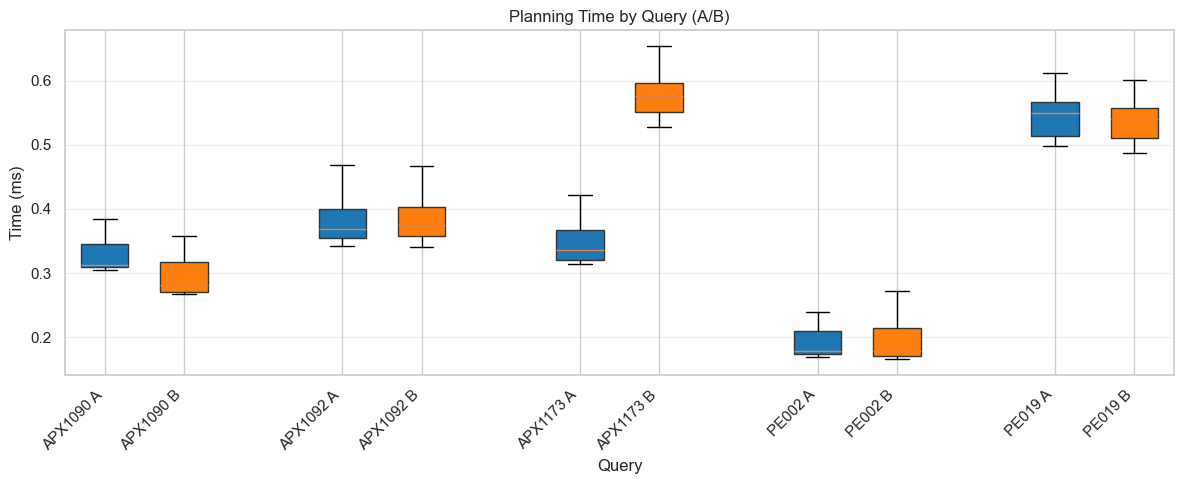

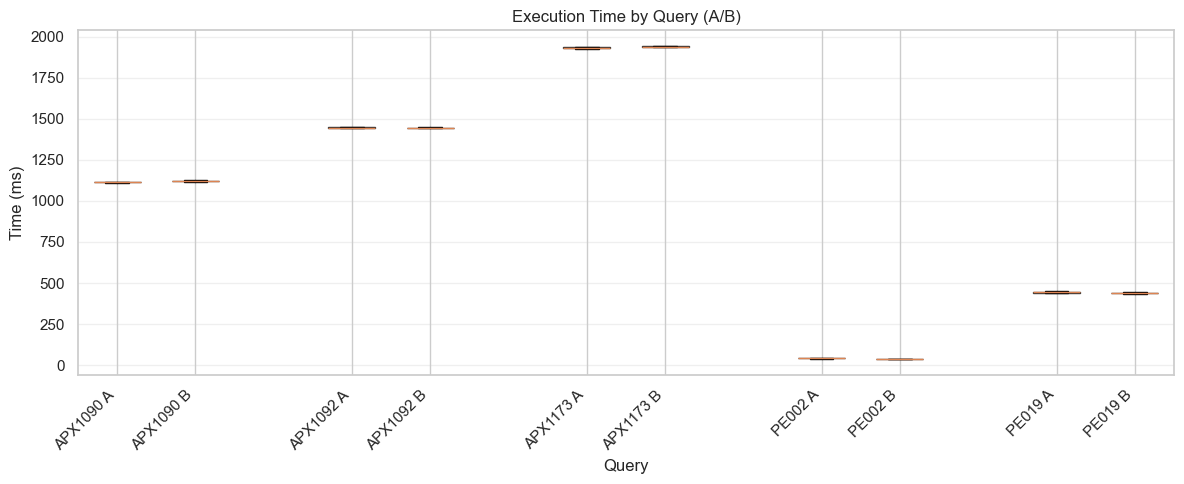

In [8]:
def plot_ab_box(df_in, metric, title, output_name):
    if metric not in df_in.columns:
        print(f"{metric} not available for boxplot.")
        return

    out_dir = Path("plots")
    out_dir.mkdir(parents=True, exist_ok=True)

    ab_plot = df_in.copy()
    ab_plot["base"] = ab_plot["test_name"].str.extract(r"^(APX\d+|PE\d+)-query")
    ab_plot["variant"] = ab_plot["test_name"].str.extract(r"-query([AB])", expand=False)
    ab_plot = ab_plot.dropna(subset=["base", "variant"])

    bases = sorted(ab_plot["base"].unique())
    data = []
    labels = []
    colors = []
    positions = []
    pos = 1

    for base in bases:
        a_vals = ab_plot[(ab_plot["base"] == base) & (ab_plot["variant"] == "A")][metric]
        b_vals = ab_plot[(ab_plot["base"] == base) & (ab_plot["variant"] == "B")][metric]
        if a_vals.empty or b_vals.empty:
            continue
        data.extend([a_vals.values, b_vals.values])
        labels.extend([f"{base} A", f"{base} B"])
        colors.extend(["#1f77b4", "#ff7f0e"])
        positions.extend([pos, pos + 1])
        pos += 3

    if not data:
        print("No A/B pairs available for boxplot.")
        return

    fig, ax = plt.subplots(figsize=(12, 5))
    bp = ax.boxplot(
        data,
        positions=positions,
        patch_artist=True,
        widths=0.6,
        showfliers=False,
    )
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_edgecolor("#333333")

    ax.set_title(title)
    ax.set_xlabel("Query")
    ax.set_ylabel("Time (ms)")
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    output_path = out_dir / f"{output_name}.svg"
    fig.savefig(output_path, format="svg")
    plt.show()

if valid.empty:
    print("No valid rows after filtering.")
else:
    plot_ab_box(valid, "planning_time_ms", "Planning Time by Query (A/B)", "planning_time_ab")
    exec_valid = filtered.copy()
    if "exit_code" in exec_valid.columns:
        exec_valid = exec_valid[exec_valid["exit_code"].fillna(0) == 0]
    if "execution_time_ms" in exec_valid.columns:
        exec_valid = exec_valid[exec_valid["execution_time_ms"].notna()]
    plot_ab_box(exec_valid, "execution_time_ms", "Execution Time by Query (A/B)", "execution_time_ab")